In [ ]:
#---EXPLORING RAW DATASET FOR UNDERSTANDING MAIN FEATURES, SIZE, AND DATA TYPES --#

In [3]:
#Importing raw dataset (Adult23.csv)
import pandas as pd

df = pd.read_csv("adult23.csv")

print("DataFrame Information:")
df.info()

print("\nData Types:")
print(df.dtypes)
df.head()


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29522 entries, 0 to 29521
Columns: 647 entries, URBRRL to POVRATTC_A
dtypes: float64(442), int64(204), object(1)
memory usage: 145.7+ MB

Data Types:
URBRRL           int64
RATCAT_A         int64
INCTCFLG_A       int64
IMPINCFLG_A      int64
LANGSPECR_A    float64
                ...   
RECTYPE          int64
IMPNUM_A         int64
WTFA_A         float64
HHX             object
POVRATTC_A     float64
Length: 647, dtype: object


,URBRRL,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,LANGSPECR_A,LANGSOC_A,LANGDOC_A,LANGMED_A,LANGHM_A,PPSU,...,PROXYREL_A,PROXY_A,AVAIL_A,HHSTAT_A,INTV_MON,RECTYPE,IMPNUM_A,WTFA_A,HHX,POVRATTC_A
0,3,4,0,0,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,1,1,1,10,1,7371.139,H029691,1.01
1,4,8,0,0,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,1,1,1,10,1,3146.794,H028812,2.49
2,4,14,0,0,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,1,1,1,10,1,10807.558,H045277,6.73
3,4,10,0,0,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,1,1,1,10,1,4661.643,H021192,3.43
4,4,5,0,0,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,1,1,1,10,1,10929.554,H025576,1.27


In [ ]:
#--DATA UNIFORMIZATION--#  

In [4]:
#Selecting chosen features for analysis

df = pd.read_csv("adult23.csv", usecols=[
    'ANXEV_A', 'AGEP_A', 'SEX_A', 'HISPALLP_A',
    'EDUCP_A', 'MLTFAMFLG_A', 
    'PCNTADLT_A', 'PCNTKIDS_A', 'OVER65FLG_A', 
    'MARSTAT_A', 'CITZNSTP_A'
])

print(df.shape)

(29522, 11)


In [5]:
#Managing null-vales for the analysis

import numpy as np

invalid_map = {
    'ANXEV_A': [7, 8, 9],
    'AGEP_A': [7, 8, 9],
    'SEX_A': [7, 8, 9],
    'HISPALLP_A': [97, 98, 99],
    'EDUCP_A': [97, 98, 99],  
    'MLTFAMFLG_A': [7, 8, 9],
    'PCNTADLT_A': [7, 8, 9],
    'PCNTKIDS_A': [7, 8, 9],
    'OVER65FLG_A': [7, 8, 9],
    'MARSTAT_A': [9, 97, 98, 99],  
    'CITZNSTP_A': [7, 8, 9]
}

for col, codes in invalid_map.items():
    df[col] = df[col].replace(codes, np.nan)

In [6]:
#Checking for Unique values in columns

for col in df.columns:
    print(f"\nUnique values in '{col}':")
    print(df[col].sort_values().unique())


Unique values in 'HISPALLP_A':
[1 2 3 4 5 6 7]

Unique values in 'CITZNSTP_A':
[ 1.  2. nan]

Unique values in 'MARSTAT_A':
[ 1.  2.  3.  4.  5.  6.  7.  8. nan]

Unique values in 'EDUCP_A':
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. nan]

Unique values in 'MLTFAMFLG_A':
[1 2]

Unique values in 'OVER65FLG_A':
[0 1]

Unique values in 'PCNTADLT_A':
[1 2 3]

Unique values in 'PCNTKIDS_A':
[0 1 2 3]

Unique values in 'SEX_A':
[ 1.  2. nan]

Unique values in 'AGEP_A':
[18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65
 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 97 99]

Unique values in 'ANXEV_A':
[ 1.  2. nan]


In [7]:
#Turning all numbers in integer

exclude_cols = ['MLTFAMFLG_A', 'OVER65FLG_A', 'PCNTADLT_A', 'PCNTKIDS_A', 'HISPALLP_A', 'AGEP_A']

for col in df.columns:
    if col not in exclude_cols:  
        df[col] = df[col].astype('Int64')

for col in df.columns:
    print(f"\nUnique values in '{col}':")
    print(df[col].sort_values().unique())


Unique values in 'HISPALLP_A':
[1 2 3 4 5 6 7]

Unique values in 'CITZNSTP_A':
<IntegerArray>
[1, 2, <NA>]
Length: 3, dtype: Int64

Unique values in 'MARSTAT_A':
<IntegerArray>
[1, 2, 3, 4, 5, 6, 7, 8, <NA>]
Length: 9, dtype: Int64

Unique values in 'EDUCP_A':
<IntegerArray>
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, <NA>]
Length: 11, dtype: Int64

Unique values in 'MLTFAMFLG_A':
[1 2]

Unique values in 'OVER65FLG_A':
[0 1]

Unique values in 'PCNTADLT_A':
[1 2 3]

Unique values in 'PCNTKIDS_A':
[0 1 2 3]

Unique values in 'SEX_A':
<IntegerArray>
[1, 2, <NA>]
Length: 3, dtype: Int64

Unique values in 'AGEP_A':
[18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65
 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 97 99]

Unique values in 'ANXEV_A':
<IntegerArray>
[1, 2, <NA>]
Length: 3, dtype: Int64


In [8]:
# Checking for missing values

missing_report = df.isnull().sum()

missing_report = missing_report[missing_report > 0]

print("Columns with missing values:")
print(missing_report)

Columns with missing values:
CITZNSTP_A    1273
MARSTAT_A     1284
EDUCP_A        144
SEX_A            6
ANXEV_A         56
dtype: int64


In [9]:
# Drop rows with missing data

df.dropna(inplace=True)

# Checking for missing values

missing_report = df.isnull().sum()

missing_report = missing_report[missing_report > 0]

print("Columns with missing values:")
print(missing_report)

Columns with missing values:
Series([], dtype: int64)


In [10]:
#Chechking for Selected Dataframe Info

print("Selected DataFrame Information:")
df.info()

Selected DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
Index: 27994 entries, 0 to 29521
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   HISPALLP_A   27994 non-null  int64
 1   CITZNSTP_A   27994 non-null  Int64
 2   MARSTAT_A    27994 non-null  Int64
 3   EDUCP_A      27994 non-null  Int64
 4   MLTFAMFLG_A  27994 non-null  int64
 5   OVER65FLG_A  27994 non-null  int64
 6   PCNTADLT_A   27994 non-null  int64
 7   PCNTKIDS_A   27994 non-null  int64
 8   SEX_A        27994 non-null  Int64
 9   AGEP_A       27994 non-null  int64
 10  ANXEV_A      27994 non-null  Int64
dtypes: Int64(5), int64(6)
memory usage: 2.7 MB


In [11]:
#Saving cleaned csv file
df.to_csv("nhis2023_cleaned.csv", index=False)

In [ ]:
#--INVESTIGATION OF SAMPLING BIAS--#

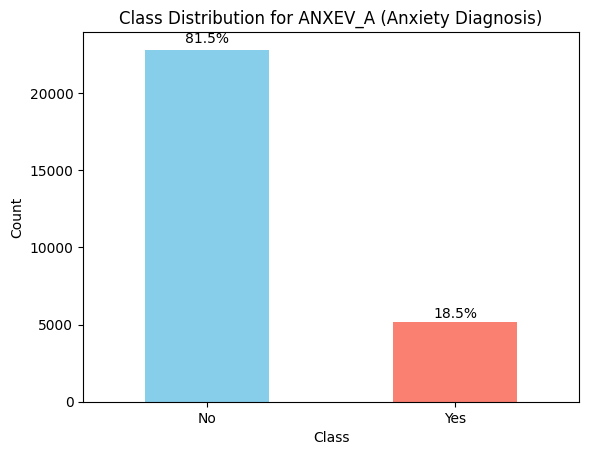

In [12]:
#Class Distribution analysis

import matplotlib.pyplot as plt
import pandas as pd

#create a dictionary for mapping classes
map_anxev = {1: "Yes", 2: "No"}
df['ANXEV_A'] = df['ANXEV_A'].map(map_anxev)

#couting frequency of values from dictionary and turning into percentages
counts = df['ANXEV_A'].value_counts(dropna=False)
percentages = df['ANXEV_A'].value_counts(normalize=True, dropna=False) * 100

#plotting bar chart
counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Class Distribution for ANXEV_A (Anxiety Diagnosis)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)

#adding labels as percentages
for i, count in enumerate(counts):
    pct = percentages.iloc[i]
    plt.text(i, count + (count * 0.01), f"{pct:.1f}%", ha='center', va='bottom', fontsize=10)

plt.show()

In [14]:
%pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 1.7 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd 
import codebook_dictionary as codebook_dict

df = pd.read_csv("nhis2023_cleaned.csv")

if "SEX_A" in df.columns:
    df["SEX_A"] = df["SEX_A"].map(codebook_dict.SEX_A)

if "ANXEV_A" in df.columns:
    df["ANXEV_A"] = df["ANXEV_A"].map(codebook_dict.ANXEV_A)

print(df.head())


   HISPALLP_A  CITZNSTP_A  MARSTAT_A  EDUCP_A  MLTFAMFLG_A  OVER65FLG_A  \
0           3           1          8        1            2            1   
1           2           1          6        8            2            1   
2           3           1          1        5            2            0   
3           2           1          1        9            2            0   
4           2           1          5        7            2            0   

   PCNTADLT_A  PCNTKIDS_A     SEX_A  AGEP_A ANXEV_A  
0           2           0     Male       67    No    
1           1           0     Male       73    No    
2           2           2     Male       48    No    
3           2           3  Female        42    No    
4           2           1  Female        50    No    


/tmp/ipykernel_16496/3612032114.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels([f'{int(x*100)}%' for x in vals])


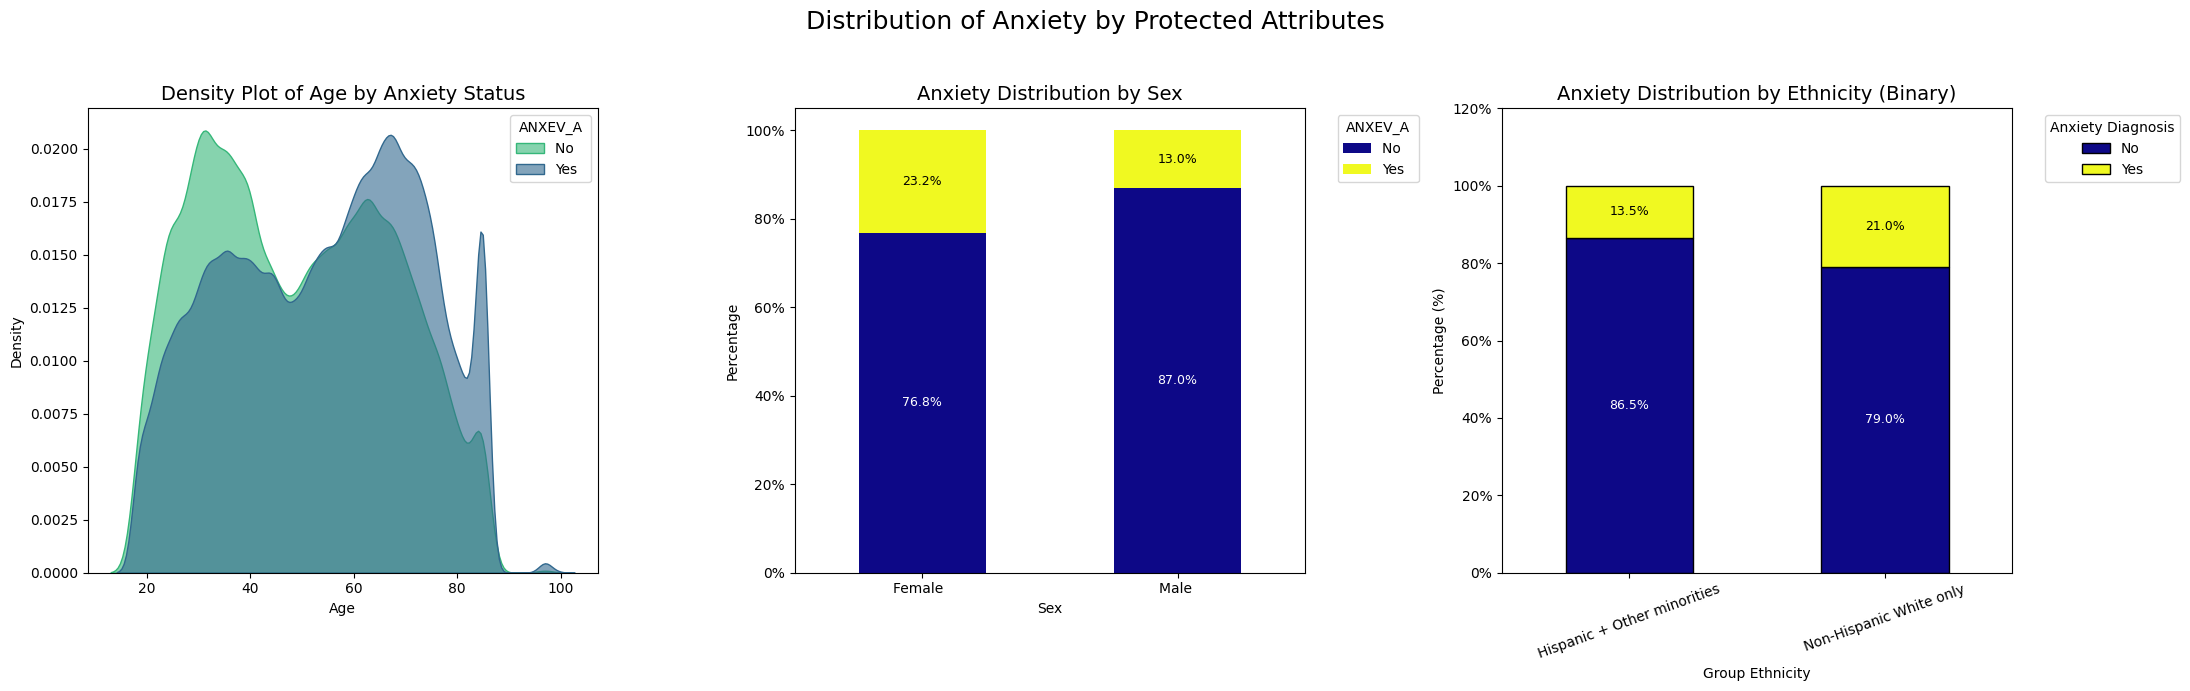

In [4]:
# Exploratory analysis of Protected Attributes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a color palette for consistency across plots
palette = sns.color_palette("viridis", 2)

#determine the best text color based on background
def get_text_color(rgb_color):
    r, g, b, _ = rgb_color
    brightness = 0.299*r + 0.587*g + 0.114*b # standard formula for dertemining "light" or "dark" color
    return 'white' if brightness < 0.5 else 'black'

# Use binary ethnicity grouping 
df['HISPALLP_BIN'] = df['HISPALLP_A'].map({
    2: 1,  # Non-Hispanic White only -- CORRECTED FROM THEPREVIOUS ONE THAT WAS 1:1 INSTEAD OF 2:1
    1: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0  # All others grouped together
})
df['HISPALLP_BIN_LABEL'] = df['HISPALLP_BIN'].map({
    1: "Non-Hispanic White only",
    0: "Hispanic + Other minorities"
})

# Create a figure with a subplot for each protected attribute
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
fig.suptitle('Distribution of Anxiety by Protected Attributes', fontsize=18)

# Density Plot for AGEP_A
sns.kdeplot(
    data=df,
    x='AGEP_A',
    hue='ANXEV_A', # create two separated density plots for Yes & No
    fill=True,
    ax=axes[0],
    palette=palette,
    common_norm=False,
    alpha=0.6,
    bw_adjust=0.5
)
axes[0].set_title('Density Plot of Age by Anxiety Status', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].legend(title='ANXEV_A', labels=df['ANXEV_A'].unique())

#Stacked Bar Chart for SEX_A & relatioship with ANXEV_A
contingency_table_sex = pd.crosstab(df['SEX_A'], df['ANXEV_A'], normalize='index') #ensure the final sum is 100%
contingency_table_sex.plot(kind='bar', stacked=True, ax=axes[1], cmap='plasma')
axes[1].set_title('Anxiety Distribution by Sex', fontsize=14)
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='ANXEV_A', labels=df['ANXEV_A'].unique(), bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

# Format y-axis ticks to show percentages
vals = axes[1].get_yticks()
axes[1].set_yticklabels([f'{int(x*100)}%' for x in vals])

# Add text labels on the bars
for container in axes[1].containers:
    for bar in container:
        height = bar.get_height()
        if height > 0.01:
            color = get_text_color(bar.get_facecolor())
            axes[1].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_y() + height / 2,
                         f'{height:.1%}',
                         ha='center', va='center', fontsize=9, color=color)

# Stacked Bar Chart for HISPALLP_A & relatioship with ANXEV_A
contingency_table_hisp = pd.crosstab(df['HISPALLP_BIN_LABEL'], df['ANXEV_A'], normalize='index')
contingency_table_hisp.plot(kind='bar', stacked=True, ax=axes[2], cmap='plasma', edgecolor="black")

axes[2].set_title('Anxiety Distribution by Ethnicity (Binary)', fontsize=14)
axes[2].set_xlabel('Group Ethnicity')
axes[2].set_ylabel('Percentage (%)')
axes[2].legend(title='Anxiety Diagnosis', labels=['No', 'Yes'], bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].tick_params(axis='x', rotation=20)

# Format y-axis ticks to show percentages
axes[2].set_yticks(axes[2].get_yticks())
axes[2].set_yticklabels([f'{int(x*100)}%' for x in axes[2].get_yticks()])

# Add text labels on the bars
for container in axes[2].containers:
    for bar in container:
        height = bar.get_height()
        if height > 0.01:
            color = get_text_color(bar.get_facecolor())
            axes[2].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_y() + height / 2,
                         f'{height:.1%}',
                         ha='center', va='center', fontsize=9, color=color)

#adjust of display
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
#--RE-SELECTING CHOSEN FEATURES AND CONFIRMING DATA UNIFORMIZATION--#

In [9]:
#Selecting chosen features for analysis
import pandas as pd

df = pd.read_csv("nhis2023_cleaned.csv", usecols=[
    'ANXEV_A', 'AGEP_A', 'SEX_A', 'HISPALLP_A',
])

df.to_csv("SelectedClean_nhis2023.csv", index=False)

In [8]:
# Checking for missing values

missing_report = df.isnull().sum()

missing_report = missing_report[missing_report > 0]

print("Columns with missing values:")
print(missing_report)

Columns with missing values:
Series([], dtype: int64)


In [35]:
#Checking for unique values
for col in df.columns:
    print(f"\nUnique values in '{col}':")
    print(df[col].sort_values().unique())


Unique values in 'HISPALLP_A':
[1 2 3 4 5 6 7]

Unique values in 'SEX_A':
[1 2]

Unique values in 'AGEP_A':
[18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65
 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 97 99]

Unique values in 'ANXEV_A':
[1 2]


In [4]:
#Checking for Selected Dataframe Info

print("Selected DataFrame Information:")
df.info()

Selected DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29460 entries, 0 to 29459
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   HISPALLP_A  29460 non-null  object
 1   SEX_A       29460 non-null  object
 2   AGEP_A      29460 non-null  int64 
 3   ANXEV_A     29460 non-null  object
dtypes: int64(1), object(3)
memory usage: 920.8+ KB


In [8]:
#CODE SOURCES:
#https://pandas.pydata.org/docs/reference/frame.html
#https://pandas.pydata.org/docs/user_guide/visualization.html

#https://github.com/lukebarousse/Python_Data_Analytics_Course.git
  #1_Basics/22_NumPy.ipynb
  #1_Basics/25_Pandas_Cleaning.ipynb
  #1_Basics/26_Pandas_Analysis.ipynb
  #1_Basics/31_Matplotlib_Pandas_Plotting.ipynb
  #2_Advanced/02_Pandas_Data_Cleaning.ipynb
  #2_Advanced/03_Pandas_Data_Management.ipynb
  #2_Advanced/17_Matplotlib_Histograms.ipynb
  #2_Advanced/13_Matplotlib_Format_Charts.ipynb
  #2_Advanced/20_Seaborn_Intro.ipynb

#Python for Data Analytics - Full Course for Beginners - https://www.youtube.com/watch?v=wUSDVGivd-8
#Python for Data Analysis: The Beginner’s Ultimate Guide - https://www.youtube.com/watch?v=gaPFwH0r4uo

#https://www.geeksforgeeks.org/data-analysis/data-analysis-with-python/

#https://www.w3schools.com/python/matplotlib_bars.asp
#https://www.w3schools.com/python/matplotlib_labels.asp
#https://www.w3schools.com/python/pandas/default.asp
#https://stackoverflow.com/questions/596216/formula-to-determine-perceived-brightness-of-rgb-color
#https://stackoverflow.com/questions/17615963/standard-rgb-to-grayscale-conversion